# Customer Churn Analytics

# Sprint 6 - Machine Learning

## Objective

The objective of this notebook is to train and evaluate classification models for predicting customer churn.

Logistic Regression will first be used as a baseline model. Additional machine learning algorithms will later be compared to identify the most suitable model for churn prediction.

In [1]:
import pandas as pd

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [3]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


In [4]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [5]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [6]:
y_pred = model.predict(X_test)

In [7]:
y_pred[:20]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])

In [8]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,1
2,0,0
3,0,0
4,0,0
5,0,1
6,0,0
7,0,0
8,0,0
9,1,0


In [9]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[927, 108],
       [165, 209]])

In [10]:
cm

array([[927, 108],
       [165, 209]])

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

Accuracy: 0.806
Precision: 0.659
Recall: 0.559
F1 Score: 0.605


In [12]:
y_pred = model.predict(X_test)

In [13]:
y_prob = model.predict_proba(X_test)[:, 1]

y_prob[:10]

array([0.0464133 , 0.68419325, 0.0603014 , 0.39859274, 0.02183171,
       0.60351226, 0.44587604, 0.12874292, 0.00290068, 0.39573055])

In [14]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 3))

ROC-AUC: 0.842


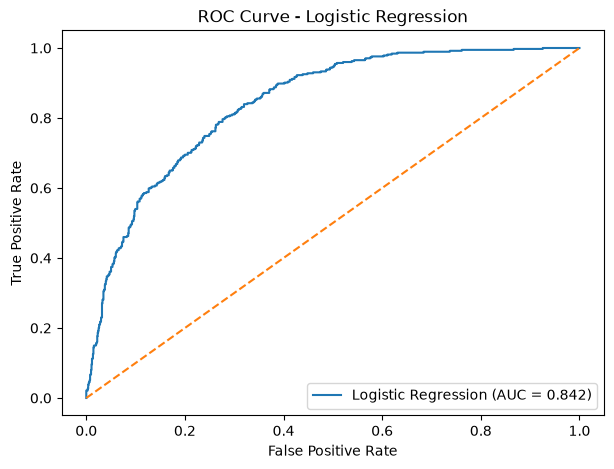

In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

## ROC Curve Analysis

The Logistic Regression model achieved a ROC-AUC score of 0.842, indicating good ability to distinguish between churned and retained customers.

The ROC curve remains substantially above the random classifier baseline. This suggests that the model can effectively rank customers according to churn risk.

However, the final classification performance depends on the selected probability threshold.

In [16]:
threshold_results = []

for threshold in [0.5, 0.4, 0.3, 0.2]:
    
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,Threshold,Precision,Recall,F1
0,0.5,0.659,0.559,0.605
1,0.4,0.570,0.666,0.614
2,0.3,0.520,0.757,0.617
3,0.2,0.467,0.856,0.604


## Classification Threshold Analysis

The default classification threshold of 0.5 identified approximately 55.9% of actual churners.

Reducing the threshold increased recall but reduced precision. At a threshold of 0.3, the model achieved approximately 75.7% recall and the highest F1-score among the tested thresholds.

A threshold of 0.3 was selected as a candidate for further evaluation because customer churn detection prioritises identifying at-risk customers. However, the final threshold should consider the financial cost of false positives and false negatives.

In [17]:
selected_threshold = 0.3

y_pred_03 = (y_prob >= selected_threshold).astype(int)

cm_03 = confusion_matrix(y_test, y_pred_03)

cm_03

array([[774, 261],
       [ 91, 283]])

## Threshold Confusion Matrix Comparison

Reducing the classification threshold from 0.5 to 0.3 increased the number of correctly identified churners from 209 to 283.

The number of missed churners decreased from 165 to 91. However, false positive predictions increased from 108 to 261.

This demonstrates the trade-off between churn detection and unnecessary customer interventions. The final classification threshold should therefore be selected based on the cost of retention campaigns and the business impact of losing a customer.

In [ ]:
# Model 2 - Decision Tree

## Objective

A Decision Tree classifier is trained to compare its churn prediction performance with the Logistic Regression baseline.

In [18]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [20]:
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [21]:
dt_pred = dt_model.predict(X_test)

In [22]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree")
print("Accuracy:", round(dt_accuracy, 3))
print("Precision:", round(dt_precision, 3))
print("Recall:", round(dt_recall, 3))
print("F1 Score:", round(dt_f1, 3))

Decision Tree
Accuracy: 0.725
Precision: 0.482
Recall: 0.479
F1 Score: 0.481


In [23]:
dt_train_pred = dt_model.predict(X_train)

dt_train_accuracy = accuracy_score(
    y_train,
    dt_train_pred
)

print(
    "Training Accuracy:",
    round(dt_train_accuracy, 3)
)

print(
    "Testing Accuracy:",
    round(dt_accuracy, 3)
)

Training Accuracy: 0.998
Testing Accuracy: 0.725


In [24]:
print("Tree Depth:", dt_model.get_depth())
print("Number of Leaves:", dt_model.get_n_leaves())

Tree Depth: 23
Number of Leaves: 1102


In [25]:
dt_pruned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)

dt_pruned.fit(X_train, y_train)

dt_pruned_pred = dt_pruned.predict(X_test)

In [26]:
print("Pruned Decision Tree")

print(
    "Accuracy:",
    round(accuracy_score(y_test, dt_pruned_pred), 3)
)

print(
    "Precision:",
    round(precision_score(y_test, dt_pruned_pred), 3)
)

print(
    "Recall:",
    round(recall_score(y_test, dt_pruned_pred), 3)
)

print(
    "F1 Score:",
    round(f1_score(y_test, dt_pruned_pred), 3)
)

Pruned Decision Tree
Accuracy: 0.796
Precision: 0.634
Recall: 0.545
F1 Score: 0.586


In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [29]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [30]:
rf_pred = rf_model.predict(X_test)

In [31]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest")
print("Accuracy:", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall:", round(rf_recall, 3))
print("F1 Score:", round(rf_f1, 3))

Random Forest
Accuracy: 0.789
Precision: 0.629
Recall: 0.503
F1 Score: 0.559


In [32]:
rf_train_pred = rf_model.predict(X_train)

print(
    "Training Accuracy:",
    round(accuracy_score(y_train, rf_train_pred), 3)
)

print(
    "Testing Accuracy:",
    round(rf_accuracy, 3)
)

Training Accuracy: 0.998
Testing Accuracy: 0.789


In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5, 10]
}

In [34]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [35]:
print("Best Parameters:")
print(grid_search.best_params_)

print(
    "Best Cross-Validation F1:",
    round(grid_search.best_score_, 3)
)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation F1: 0.568


In [36]:
tuned_rf = grid_search.best_estimator_

tuned_rf_pred = tuned_rf.predict(X_test)

tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_pred)
tuned_rf_precision = precision_score(y_test, tuned_rf_pred)
tuned_rf_recall = recall_score(y_test, tuned_rf_pred)
tuned_rf_f1 = f1_score(y_test, tuned_rf_pred)

print("Tuned Random Forest")
print("Accuracy:", round(tuned_rf_accuracy, 3))
print("Precision:", round(tuned_rf_precision, 3))
print("Recall:", round(tuned_rf_recall, 3))
print("F1 Score:", round(tuned_rf_f1, 3))

Tuned Random Forest
Accuracy: 0.801
Precision: 0.667
Recall: 0.497
F1 Score: 0.57


In [37]:
tuned_rf_train_pred = tuned_rf.predict(X_train)

print(
    "Training Accuracy:",
    round(accuracy_score(y_train, tuned_rf_train_pred), 3)
)

print(
    "Testing Accuracy:",
    round(tuned_rf_accuracy, 3)
)

Training Accuracy: 0.829
Testing Accuracy: 0.801


# Model 4 - K-Nearest Neighbours (KNN)

## Objective

A K-Nearest Neighbours classifier is trained to evaluate customer churn using similarity between customer feature profiles.

The scaled dataset is used because KNN is a distance-based machine learning algorithm.

In [38]:
from sklearn.neighbors import KNeighborsClassifier

In [39]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [40]:
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

In [41]:
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("KNN")
print("Accuracy:", round(knn_accuracy, 3))
print("Precision:", round(knn_precision, 3))
print("Recall:", round(knn_recall, 3))
print("F1 Score:", round(knn_f1, 3))

KNN
Accuracy: 0.763
Precision: 0.554
Recall: 0.551
F1 Score: 0.552


In [42]:
knn_results = []

for k in [3, 5, 7, 9, 11, 15, 21]:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    knn_results.append({
        "K": k,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

knn_df = pd.DataFrame(knn_results)

knn_df.round(3)

,K,Accuracy,Precision,Recall,F1
0,3,0.760,0.548,0.548,0.548
1,5,0.763,0.554,0.551,0.552
2,7,0.771,0.571,0.551,0.561
3,9,0.773,0.573,0.567,0.570
4,11,0.779,0.589,0.559,0.573
5,15,0.779,0.588,0.556,0.571
6,21,0.784,0.597,0.570,0.583


# Final Model Selection

Hyperparameter selection should be performed using the training dataset and cross-validation. The test dataset is reserved for final model evaluation.

In [43]:
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalue

In [44]:
print("Best K:", knn_grid.best_params_)
print(
    "Best CV F1:",
    round(knn_grid.best_score_, 3)
)

Best K: {'n_neighbors': 21}
Best CV F1: 0.598


In [45]:
best_knn = knn_grid.best_estimator_

In [46]:
best_knn = knn_grid.best_estimator_

best_knn_pred = best_knn.predict(X_test)
best_knn_prob = best_knn.predict_proba(X_test)[:, 1]

knn_accuracy = accuracy_score(y_test, best_knn_pred)
knn_precision = precision_score(y_test, best_knn_pred)
knn_recall = recall_score(y_test, best_knn_pred)
knn_f1 = f1_score(y_test, best_knn_pred)
knn_auc = roc_auc_score(y_test, best_knn_prob)

print("Tuned KNN")
print("Accuracy:", round(knn_accuracy, 3))
print("Precision:", round(knn_precision, 3))
print("Recall:", round(knn_recall, 3))
print("F1 Score:", round(knn_f1, 3))
print("ROC-AUC:", round(knn_auc, 3))

Tuned KNN
Accuracy: 0.784
Precision: 0.597
Recall: 0.57
F1 Score: 0.583
ROC-AUC: 0.826


In [47]:
# Logistic Regression
logistic_auc = roc_auc_score(
    y_test,
    model.predict_proba(X_test)[:, 1]
)

# Pruned Decision Tree
dt_auc = roc_auc_score(
    y_test,
    dt_pruned.predict_proba(X_test)[:, 1]
)

# Tuned Random Forest
rf_auc = roc_auc_score(
    y_test,
    tuned_rf.predict_proba(X_test)[:, 1]
)

print("Logistic AUC:", round(logistic_auc, 3))
print("Decision Tree AUC:", round(dt_auc, 3))
print("Random Forest AUC:", round(rf_auc, 3))

Logistic AUC: 0.842
Decision Tree AUC: 0.827
Random Forest AUC: 0.845


In [48]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Pruned Decision Tree",
        "Tuned Random Forest",
        "Tuned KNN"
    ],
    "Accuracy": [
        accuracy,
        accuracy_score(y_test, dt_pruned_pred),
        tuned_rf_accuracy,
        knn_accuracy
    ],
    "Precision": [
        precision,
        precision_score(y_test, dt_pruned_pred),
        tuned_rf_precision,
        knn_precision
    ],
    "Recall": [
        recall,
        recall_score(y_test, dt_pruned_pred),
        tuned_rf_recall,
        knn_recall
    ],
    "F1 Score": [
        f1,
        f1_score(y_test, dt_pruned_pred),
        tuned_rf_f1,
        knn_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        dt_auc,
        rf_auc,
        knn_auc
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806,0.659,0.559,0.605,0.842
1,Pruned Decision Tree,0.796,0.634,0.545,0.586,0.827
2,Tuned Random Forest,0.801,0.667,0.497,0.570,0.845
3,Tuned KNN,0.784,0.597,0.570,0.583,0.826


# Final Model Selection

Four classification models were evaluated for customer churn prediction: Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbours.

The tuned Random Forest achieved the highest ROC-AUC score of 0.845. However, Logistic Regression achieved the highest F1-score of 0.605 and demonstrated stronger recall than the Random Forest at the default classification threshold.

Logistic Regression was selected as the final model because it provides strong predictive performance, churn probability estimates, and greater interpretability for business stakeholders.

Threshold analysis also demonstrated that reducing the classification threshold to 0.3 increased recall from 55.9% to 75.7%, allowing the model to identify a larger proportion of at-risk customers.

The final threshold should ultimately be selected based on the financial cost of customer churn and retention interventions.

In [ ]:
# Logistic Regression Coefficient Analysis

The coefficients of the final Logistic Regression model are analysed to understand which customer characteristics are associated with increased or decreased churn probability.

In [49]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
10,InternetService_Fiber optic,1.180666
3,TotalCharges,0.527772
28,PaymentMethod_Electronic check,0.392775
21,StreamingTV_Yes,0.374831
26,PaperlessBilling_Yes,0.374218
23,StreamingMovies_Yes,0.373193
9,MultipleLines_Yes,0.361646
0,SeniorCitizen,0.147911
29,PaymentMethod_Mailed check,0.081866
17,DeviceProtection_Yes,0.033106


## Coefficient Interpretation and Comparison with EDA

The Logistic Regression coefficients generally support the findings from exploratory data analysis.

Fiber Optic internet and Electronic Check payment were positively associated with churn. In contrast, longer tenure, one-year and two-year contracts, Online Security, and Tech Support were negatively associated with churn.

The two-year contract and customer tenure showed the strongest negative coefficients, supporting the EDA finding that long-term and established customers are less likely to churn.

An interesting difference was observed for Monthly Charges. EDA showed that churned customers generally had higher monthly charges, while the multivariable Logistic Regression coefficient was negative.

This difference highlights that exploratory analysis examines variables individually, whereas Logistic Regression estimates the association of each feature while accounting for other model features. Correlations between Monthly Charges, Total Charges, tenure, internet service, and service subscriptions may influence the coefficient.

These results represent statistical associations and should not be interpreted as causal relationships.

In [50]:
redundant_columns = [
    "OnlineSecurity_No internet service",
    "OnlineBackup_No internet service",
    "DeviceProtection_No internet service",
    "TechSupport_No internet service",
    "StreamingTV_No internet service",
    "StreamingMovies_No internet service"
]

In [51]:
X_train_clean = X_train.drop(
    columns=redundant_columns
)

X_test_clean = X_test.drop(
    columns=redundant_columns
)

print("Before:", X_train.shape)
print("After:", X_train_clean.shape)

Before: (5634, 30)
After: (5634, 24)


In [52]:
clean_logistic = LogisticRegression(
    max_iter=1000,
    random_state=42
)

clean_logistic.fit(
    X_train_clean,
    y_train
)

clean_pred = clean_logistic.predict(
    X_test_clean
)

clean_prob = clean_logistic.predict_proba(
    X_test_clean
)[:, 1]

In [53]:
print("Clean Logistic Regression")

print(
    "Accuracy:",
    round(accuracy_score(y_test, clean_pred), 3)
)

print(
    "Precision:",
    round(precision_score(y_test, clean_pred), 3)
)

print(
    "Recall:",
    round(recall_score(y_test, clean_pred), 3)
)

print(
    "F1 Score:",
    round(f1_score(y_test, clean_pred), 3)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, clean_prob), 3)
)

Clean Logistic Regression
Accuracy: 0.806
Precision: 0.659
Recall: 0.559
F1 Score: 0.605
ROC-AUC: 0.842


## Redundant Feature Removal

Several one-hot encoded features represented the same underlying condition of a customer having no internet service.

Six redundant indicators were removed while retaining `InternetService_No`.

After removing these features, Logistic Regression achieved identical evaluation metrics to the original model. This reduced feature redundancy without measurable loss in predictive performance.

The cleaned Logistic Regression model was therefore selected as the final model.

In [54]:
clean_coefficients = pd.DataFrame({
    "Feature": X_train_clean.columns,
    "Coefficient": clean_logistic.coef_[0]
})

clean_coefficients = clean_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

clean_coefficients

,Feature,Coefficient
10,InternetService_Fiber optic,1.021015
3,TotalCharges,0.528342
22,PaymentMethod_Electronic check,0.385337
20,PaperlessBilling_Yes,0.372822
9,MultipleLines_Yes,0.329859
16,StreamingTV_Yes,0.310931
17,StreamingMovies_Yes,0.309489
0,SeniorCitizen,0.145358
23,PaymentMethod_Mailed check,0.073726
5,Partner_Yes,0.021569


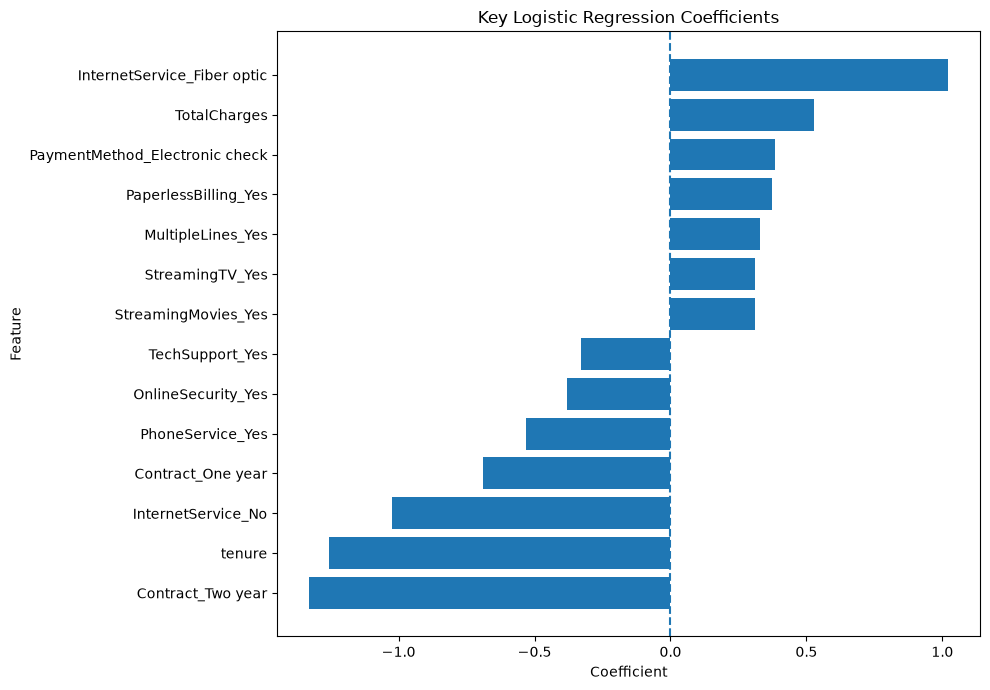

In [55]:
import matplotlib.pyplot as plt

top_features = pd.concat([
    clean_coefficients.head(7),
    clean_coefficients.tail(7)
])

top_features = top_features.sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Key Logistic Regression Coefficients"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Final Model Interpretation

The coefficient analysis indicates that Fiber Optic internet and Electronic Check payment are strongly associated with increased churn odds.

Longer customer tenure and long-term contracts show strong negative associations with churn. Online Security and Tech Support are also associated with reduced churn odds.

These machine learning findings largely support the patterns identified during exploratory data analysis.